In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import Counter   # used for tokenization

# libraries to deal with stopwords
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/Wealthtender Capstone/Data/Processed /wealthtender_reviews_clean.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(DATA_PATH, encoding="utf-8", low_memory=False)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(3)

Shape: (4731, 25)
Columns: ['ID', 'Title', 'Content', 'Date', '_custom_form', 'notification_name', 'notification_page', '_custom_relationship', '_custom_compensation', '_custom_conflicts', '_custom_disclosure', 'Status', 'Post Modified Date', 'reviewer_name', 'acf_rating', 'advisor_id', 'advisor_name', 'review_text_raw', 'rating', 'review_date', 'token_count', 'review_text_clean', 'clean_token_count', 'raw_len', 'clean_len']


,ID,Title,Content,Date,_custom_form,notification_name,notification_page,_custom_relationship,_custom_compensation,_custom_conflicts,...,advisor_id,advisor_name,review_text_raw,rating,review_date,token_count,review_text_clean,clean_token_count,raw_len,clean_len
0,55476,Absolutely amazing!!!,Omar Morillo is an exceptional wealth advisor ...,2026-01-07 15:15:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",Omar Morillo is an exceptional wealth advisor ...,5.0,2026-01-07 15:15:00,93,omar morillo is an exceptional wealth advisor ...,93,516,516
1,55446,It is Simply wonderful working with Omar,Omar is an exceptional advisor. Beyond the out...,2026-01-06 20:44:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",Omar is an exceptional advisor. Beyond the out...,5.0,2026-01-06 20:44:00,47,omar is an exceptional advisor. beyond the out...,47,316,316
2,55445,President,We are extremely happy with the work Omar Mori...,2026-01-06 20:44:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",We are extremely happy with the work Omar Mori...,5.0,2026-01-06 20:44:00,142,we are extremely happy with the work omar mori...,142,891,888


# 1. Data revision

In [ ]:
print(df.dtypes)

ID                        int64
Title                    object
Content                  object
Date                     object
_custom_form              int64
notification_name        object
notification_page        object
_custom_relationship     object
_custom_compensation     object
_custom_conflicts        object
_custom_disclosure       object
Status                   object
Post Modified Date       object
reviewer_name            object
acf_rating              float64
advisor_id               object
advisor_name             object
review_text_raw          object
rating                  float64
review_date              object
token_count               int64
review_text_clean        object
clean_token_count         int64
raw_len                   int64
clean_len                 int64
dtype: object


In [ ]:
print("Unique advisor NAMES:",df['advisor_name'].nunique())
print("Unique advisor IDs:", df['advisor_id'].nunique())

Unique advisor NAMES: 361
Unique advisor IDs: 336


In [ ]:
print(df.isna().mean().sort_values(ascending=False).head(15))  # missingness

_custom_disclosure      0.911435
rating                  0.013739
acf_rating              0.013739
reviewer_name           0.013739
_custom_conflicts       0.011203
_custom_compensation    0.011203
_custom_relationship    0.010357
notification_page       0.000211
notification_name       0.000211
advisor_name            0.000211
advisor_id              0.000211
Title                   0.000000
_custom_form            0.000000
ID                      0.000000
Content                 0.000000
dtype: float64


In [ ]:
# check all advisors
# df['advisor_name'].drop_duplicates().sort_values().to_list()

In [ ]:
# how many advisors are there & what's the one with the most reviews
df['advisor_id'].value_counts().sort_values(ascending=False)

,count
advisor_id,
https://wealthtender.com/advisory-firms/berkshire-money-management/,141
https://wealthtender.com/advisory-firms/twin-peaks-wealth-advisors/,94
https://wealthtender.com/financial-advisors/terry-scipio-clu/,91
https://wealthtender.com/advisory-firms/pax-financial-group/,87
https://wealthtender.com/advisory-firms/edge-financial-advisors/,66
...,...
https://wealthtender.com/financial-advisors/jonathon-armstrong-cfp-abfp/,1
https://wealthtender.com/financial-advisors/scott-gerlach-cfp/,1
https://wealthtender.com/financial-advisors/sarah-k-charles/,1


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df["review_year"] = df["Date"].dt.year

In [ ]:
df["review_year"].value_counts().sort_index()

,count
review_year,
2008,1
2014,1
2016,11
2017,11
2018,32
2019,32
2020,46
2021,159
2022,524


## 1.1. Filter dates
Since there are only two reviews before 2016 we'll drop these.

In [ ]:
# Filter the DataFrame to keep only rows that are after 2014
df = df[df['review_year'] > 2014]

In [ ]:
df["review_year"].value_counts().sort_index()

,count
review_year,
2016,11
2017,11
2018,32
2019,32
2020,46
2021,159
2022,524
2023,1024
2024,1249


In [ ]:
df['ID'].size

4731

## 1.2. Drop duplicates

In [ ]:
df= df.drop_duplicates()

In [ ]:
df['ID'].size

4723

## 1.3. Tokenize review **text**

In [ ]:
# length validation
TEXT_COL = "review_text_clean"
ID_COL   = "advisor_name"

df["char_len"] = df[TEXT_COL].str.len()
df["word_len"] = df[TEXT_COL].str.split().str.len()

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,4723.000000,4723.000000
mean,457.795681,78.059073
std,386.569928,66.385601
min,8.000000,1.000000
25%,225.000000,38.000000
50%,377.000000,64.000000
75%,596.500000,102.000000
max,11663.000000,2048.000000


In [ ]:
from collections import Counter

def tokenize(text):
    return text.split()

df["tokens"] = df[TEXT_COL].apply(tokenize)
df["n_tokens"] = df["tokens"].apply(len)

df[["n_tokens"]].describe()

,n_tokens
count,4723.000000
mean,78.059073
std,66.385601
min,1.000000
25%,38.000000
50%,64.000000
75%,102.000000
max,2048.000000


## 1.4. Remove stopwords

In [ ]:
# Most used tokens
all_tokens = [t for tokens in df["tokens"] for t in tokens]

token_counts = Counter(all_tokens)
token_counts.most_common(20)

[('and', 17826),
 ('to', 12217),
 ('the', 8620),
 ('i', 7999),
 ('a', 7739),
 ('with', 6618),
 ('my', 5780),
 ('of', 5319),
 ('financial', 5208),
 ('for', 5120),
 ('our', 4772),
 ('in', 4746),
 ('is', 4604),
 ('we', 4582),
 ('he', 4261),
 ('have', 3926),
 ('that', 3247),
 ('has', 3129),
 ('his', 2899),
 ('been', 2660)]

In [ ]:
# not only remove stopwords but also non-informative words

EN_STOPWORDS = set(stopwords.words("english"))

DOMAIN_STOPWORDS = {
    "advisor",
    "advisors",
    "financial",
    "finance",
    "wealth",
    "firm",
    "company",
    "client", "clients",
    "also",
    "would",
    "make",
    "always",
    "looking",
    "years",
    "know",
    "with", "with.",
    "anyone",
    "scale",
    "recommend", # most used word after dropping stopwords
    "berkshire", # berkshire money is one of the advisors
    "lorem", "ipsum"
}

STOPWORDS = EN_STOPWORDS.union(DOMAIN_STOPWORDS)

In [ ]:
# clean tokens with stopwords removed

def remove_stopwords(tokens, stopwords=STOPWORDS):
    return [t for t in tokens if t not in stopwords and len(t) > 2]

df["tokens_nostop"] = df["tokens"].apply(remove_stopwords)
df["n_tokens_nostop"] = df["tokens_nostop"].apply(len)

df[["n_tokens", "n_tokens_nostop"]].describe()

,n_tokens,n_tokens_nostop
count,4723.000000,4723.000000
mean,78.059073,37.013551
std,66.385601,31.880459
min,1.000000,1.000000
25%,38.000000,18.000000
50%,64.000000,30.000000
75%,102.000000,49.000000
max,2048.000000,934.000000


## 1.5. Additional cleaning
We need to embed only text that reflects the client's own language and not platform questions, so we:

1. Remove question prompts and other suspicious text non-related to client feedback.

2. For text like: "how well do you feel your advisor is addressing your financial planning and wealth management needs? scale from 1–10. 10" and related platform generated questions

In [ ]:
# check for suspect phrases

SUSPECT_PHRASES = [
    "things value advisor",
    "feel first",
    "first capital",
    "addressing planning management",
    "planning management needs",
    "available answer questions"
]

# Find reviews containing any suspect phrase (in cleaned text)
mask = df["review_text_clean"].str.contains("|".join(SUSPECT_PHRASES), case=False, na=False)

cols = ["advisor_name", "advisor_id", "acf_rating", "Content", "review_text_clean"]
df.loc[mask, cols].head(10)

,advisor_name,advisor_id,acf_rating,Content,review_text_clean
4094,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Amar Shaw has been our financial advisor for a...,amar shaw has been our financial advisor for a...
4095,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Client First Capital with Amar Shaw is the bes...,client first capital with amar shaw is the bes...
4099,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,I have worked with Amar Shah for several years...,i have worked with amar shah for several years...
4100,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,We wouldn’t go anywhere else for our financial...,we wouldn’t go anywhere else for our financial...
4101,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,We have known and worked with Amar Shah since ...,we have known and worked with amar shah since ...
4279,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Top things you value in your advisor:\n•\tMy a...,top things you value in your advisor: my advis...
4288,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Top things you value in your advisor:\n•\tMy a...,top things you value in your advisor: my advis...
4290,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Top things you value in your advisor:\n•\tMy a...,top things you value in your advisor: my advis...
4293,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Top things you value in your advisor:\n•\tMy a...,top things you value in your advisor: my advis...
4294,"Amar Shah, CFA, CFP®",https://wealthtender.com/financial-advisors/am...,5.0,Top things you value in your advisor:\n•\tMy a...,top things you value in your advisor: my advis...


In [ ]:
n_total = len(df)
n_suspect = mask.sum()

print(f"Suspect reviews: {n_suspect} / {n_total} = {n_suspect/n_total:.1%}")

Suspect reviews: 31 / 4723 = 0.7%


In [ ]:
import re

PROMPT_PATTERNS = [
    r"things\s+you\s+value\s+in\s+your\s+advisor[:\s]*",
    r"top\sthings\s+you\s+value\s+in\s+your\s+advisor[:\s]*",
    r"things\s+value\s+advisor[:\s]*",
    r"how\s+well\s+do\s+you\s+feel.*?\?",
    r"how\s+would\s+you\s+describe.*?\?",
    r"how\s+likely.*?\?",
    r"if\s+you\s+have\s+any\s+other\s+feedback\s+for\s+us[:\s]*", # if you have any other feedback for us
    r"\bwe\s*'?\s*d\s+love\s+to\s+hear\s+from\s+you\b[^\w]*", # we'd love to hear from you
    r"on\s+a\s+scale\s+of\s+\d+\s*[-–]\s*\d+[:\s]*",
    r"scale\s+from\s+\d+\s*[-–]\s*\d+",
    r"please\s+rate[:\s]*",
    r"&amp\d+",
    r"client first capital" # "Client First Capital" is a company
]

prompt_regex = re.compile("|".join(PROMPT_PATTERNS), flags=re.IGNORECASE)

def strip_prompts(text: str) -> str:
    if not isinstance(text, str):
        return text
    # remove prompt fragments
    cleaned = prompt_regex.sub(" ", text)
    # normalize whitespace
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [ ]:
# clean HTML entities like "&amp"
import html

def decode_html_entities(text):
    if not isinstance(text, str):
        return text
    return html.unescape(text)

df["review_text_clean2"] = df["review_text_clean"].apply(decode_html_entities)

# clean non-breaking spaces with regular spaces
def normalize_whitespace(text):
    if not isinstance(text, str):
        return text
    # Replace non-breaking spaces with regular spaces
    text = text.replace("\xa0", " ")
    # Collapse multiple spaces
    text = " ".join(text.split())
    return text

df["review_text_clean2"] = df["review_text_clean2"].apply(normalize_whitespace)

In [ ]:
df["review_text_clean2"] = df["review_text_clean2"].apply(strip_prompts)

In [ ]:
# Remove rows where there's no text
df = df[
    df["review_text_clean2"]
      .notna()
    & df["review_text_clean2"].str.strip().ne("")
].copy()

In [ ]:
check = df.loc[mask, ["review_text_clean", "review_text_clean2"]].tail(10)
check

,review_text_clean,review_text_clean2
4309,top things you value in your advisor: my advis...,my advisor understands my needs & goals my adv...
4310,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...
4313,top things you value in your advisor: my advis...,my advisor serves as a professional sounding b...
4315,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...
4316,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...
4318,top things you value in your advisor: my advis...,my advisor understands my needs & goals my adv...
4319,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...
4320,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...
4321,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...
4327,top things you value in your advisor: my advis...,my advisor is easy to reach & responds quickly...


In [ ]:
TEXT_COL = "review_text_clean2"
# ID_COL   = "advisor_name"

df["tokens"] = df[TEXT_COL].apply(tokenize)
df["n_tokens"] = df["tokens"].apply(len)

In [ ]:
# remove stopwords
df["tokens_nostop"] = df["tokens"].apply(remove_stopwords)
df["n_tokens_nostop"] = df["tokens_nostop"].apply(len)

df[["n_tokens", "n_tokens_nostop"]].describe()

,n_tokens,n_tokens_nostop
count,4723.000000,4723.000000
mean,77.629896,36.789541
std,66.340645,31.865601
min,1.000000,1.000000
25%,38.000000,17.000000
50%,63.000000,30.000000
75%,101.000000,48.000000
max,2048.000000,934.000000


## 1.6. Distributions & N-grams

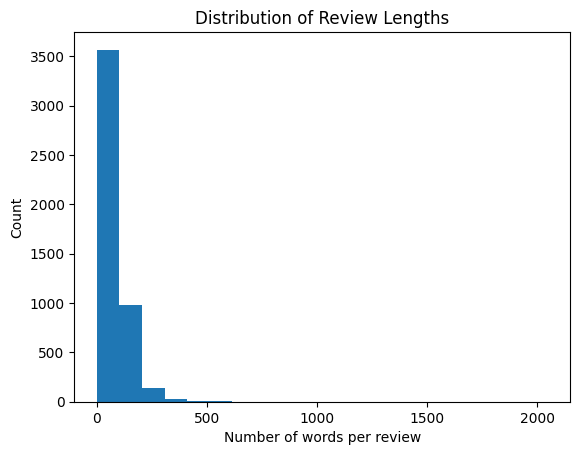

In [ ]:
# visualize distributions
plt.hist(df["word_len"], bins=20)
plt.xlabel("Number of words per review")
plt.ylabel("Count")
plt.title("Distribution of Review Lengths")
plt.show()

### Unigrams

In [ ]:
df["tokens_nostop"].head()

,tokens_nostop
0,"[omar, morillo, exceptional, person., goes, be..."
1,"[omar, exceptional, advisor., beyond, outstand..."
2,"[extremely, happy, work, omar, morillo, done, ..."
3,"[available, questions, concerns,, schedules, r..."
4,"[omar, referred, accountant, help, setup, defi..."


In [ ]:
# most common words after we removed stopwords
all_tokens_clean = [t for tokens in df["tokens_nostop"] for t in tokens]
Counter(all_tokens_clean).most_common(25)

[('working', 1265),
 ('highly', 1165),
 ('time', 984),
 ('retirement', 956),
 ('great', 947),
 ('team', 899),
 ('feel', 882),
 ('planning', 846),
 ('help', 803),
 ('work', 797),
 ('plan', 794),
 ('best', 787),
 ('helped', 697),
 ('investment', 661),
 ('advice', 625),
 ('questions', 588),
 ('goals', 580),
 ('family', 547),
 ('trust', 534),
 ('years.', 531),
 ('like', 526),
 ('understand', 519),
 ('many', 500),
 ('money', 495),
 ('personal', 485)]

### Bigrams

In [ ]:
from nltk.util import bigrams

def make_bigrams(tokens):
    return list(bigrams(tokens))

df["bigrams"] = df["tokens_nostop"].apply(make_bigrams)

all_bigrams = [bg for bgs in df["bigrams"] for bg in bgs]
Counter(all_bigrams).most_common(20)

[(('took', 'time'), 176),
 (('takes', 'time'), 155),
 (('feel', 'confident'), 152),
 (('feel', 'like'), 147),
 (('look', 'forward'), 134),
 (('long', 'term'), 127),
 (('time', 'understand'), 125),
 (('best', 'interests'), 114),
 (('answer', 'questions'), 114),
 (('peace', 'mind'), 112),
 (('best', 'interest'), 88),
 (('pleasure', 'working'), 87),
 (('money', 'management'), 84),
 (('feel', 'comfortable'), 79),
 (('pleasure', 'work'), 79),
 (('retirement', 'planning'), 73),
 (('highly', 'recommend!'), 73),
 (('easy', 'work'), 71),
 (('great', 'work'), 69),
 (('say', 'enough'), 67)]

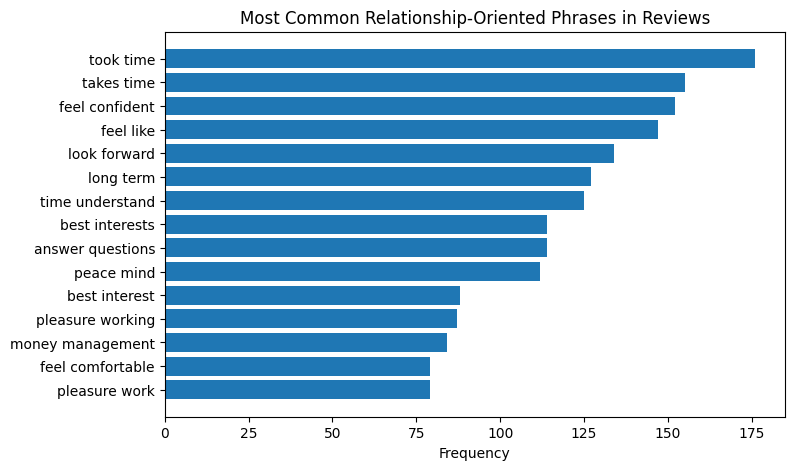

In [ ]:
top_bigrams = Counter(all_bigrams).most_common(15)
labels = [" ".join(bg) for bg, _ in top_bigrams]
counts = [c for _, c in top_bigrams]

plt.figure(figsize=(8,5))
plt.barh(labels[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.title("Most Common Relationship-Oriented Phrases in Reviews")
plt.show()

**Comment:** From the bigrams after removing stopwords, it appears that we mostly are left with relationship-heavy reviews rather than performance-heavy. This bigrams emphasize characteristics such as:
* attentiveness (e.g. _took time_ or _takes time_)
* long-horizon guidance (e.g. _long term, or retirement planning_)
* alignment (e.g. _best interests_, _answer questions_)
* emotional outcomes (e.g. _peace mind_)

So, basically clients consistently emphasize listening, trust, time, and peace of mind.

## Trigrams

In [ ]:
from nltk.util import trigrams

def make_trigrams(tokens):
    return list(trigrams(tokens))

df["trigrams"] = df["tokens_nostop"].apply(make_trigrams)

all_trigrams = [bg for bgs in df["trigrams"] for bg in bgs]
Counter(all_trigrams).most_common(20)

[(('took', 'time', 'understand'), 63),
 (('available', 'answer', 'questions'), 43),
 (('time', 'understand', 'goals'), 37),
 (('look', 'forward', 'working'), 33),
 (('say', 'enough', 'good'), 32),
 (('every', 'step', 'way.'), 32),
 (('one', 'best', 'decisions'), 30),
 (("can't", 'say', 'enough'), 30),
 (('look', 'forward', 'continuing'), 29),
 (('takes', 'time', 'understand'), 29),
 (('enough', 'good', 'things'), 28),
 (('takes', 'time', 'explain'), 27),
 (('best', 'interests', 'mind.'), 24),
 (('best', 'interests', 'heart.'), 24),
 (('short', 'long', 'term'), 21),
 (('done', 'great', 'job'), 20),
 (('easy', 'work', 'with,'), 19),
 (('easy', 'reach', 'responds'), 19),
 (('can’t', 'say', 'enough'), 18),
 (('took', 'time', 'get'), 18)]

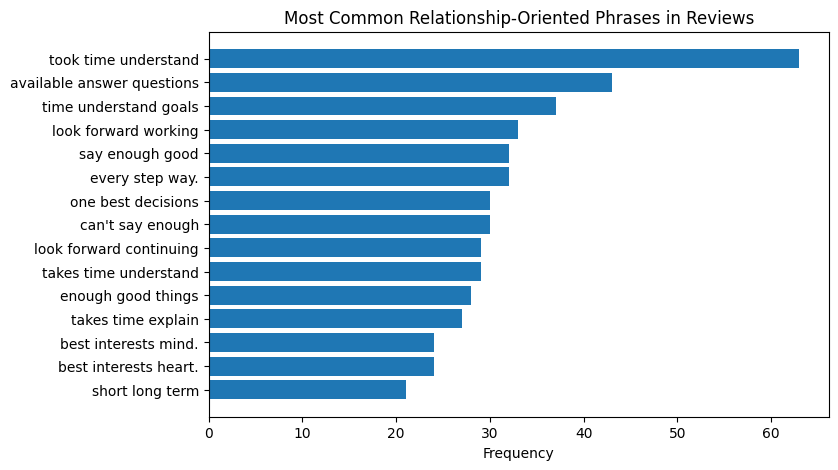

In [ ]:
top_trigrams = Counter(all_trigrams).most_common(15)
labels = [" ".join(bg) for bg, _ in top_trigrams]
counts = [c for _, c in top_trigrams]

plt.figure(figsize=(8,5))
plt.barh(labels[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.title("Most Common Relationship-Oriented Phrases in Reviews")
plt.show()

## Distributions

In [ ]:
advisor_lang = (
    df.groupby("advisor_id")["n_tokens_nostop"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "n_reviews",
          "sum": "total_tokens",
          "mean": "avg_tokens"
      })
)

advisor_lang.describe()

,n_reviews,total_tokens,avg_tokens
count,336.000000,336.000000,336.000000
mean,14.053571,517.095238,38.752601
std,16.107200,579.298740,23.085680
min,1.000000,1.000000,1.000000
25%,5.000000,146.500000,28.000000
50%,9.000000,338.500000,35.788889
75%,17.250000,690.250000,46.587500
max,141.000000,4864.000000,331.666667


**Comemnt:** As we could see from the distribution above and in this table, the distribution is skewed to the right. The median advisor has 9 reviews, ~339 tokens in total and ~36 tokens per review.

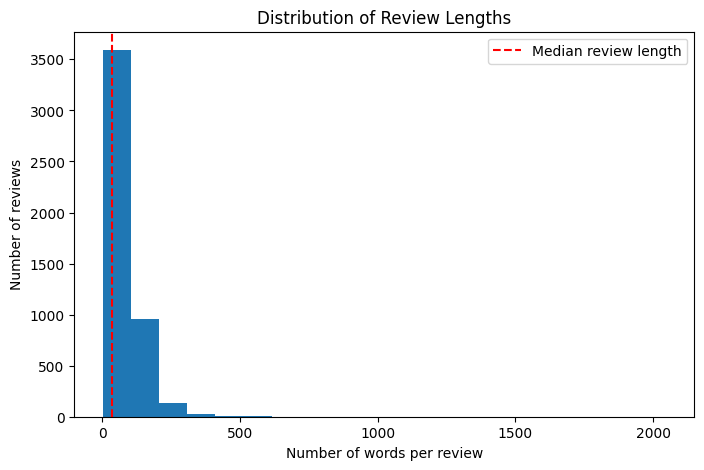

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["n_tokens"], bins=20)
plt.axvline(36, color="red", linestyle="--", label="Median review length")
plt.xlabel("Number of words per review")
plt.ylabel("Number of reviews")
plt.title("Distribution of Review Lengths")
plt.legend()
plt.show()

In [ ]:
# check reviews sparsity

print("Proportion of advisors w/ less than 100 total tokens:" ,(advisor_lang["total_tokens"] < 100).mean())
print("Proportion of advisors w/ less than 300 total tokens:", (advisor_lang["total_tokens"] < 300).mean())

Proportion of advisors w/ less than 100 total tokens: 0.19642857142857142
Proportion of advisors w/ less than 300 total tokens: 0.44345238095238093


In [ ]:
MIN_TOTAL_TOKENS = 150

eligible_advisors = advisor_lang[
    advisor_lang["total_tokens"] >= MIN_TOTAL_TOKENS
].index

df_nlp = df[df["advisor_id"].isin(eligible_advisors)].copy()

print("Advisors eligible:", len(eligible_advisors))
print("Reviews used:", len(df_nlp))

Advisors eligible: 250
Reviews used: 4509


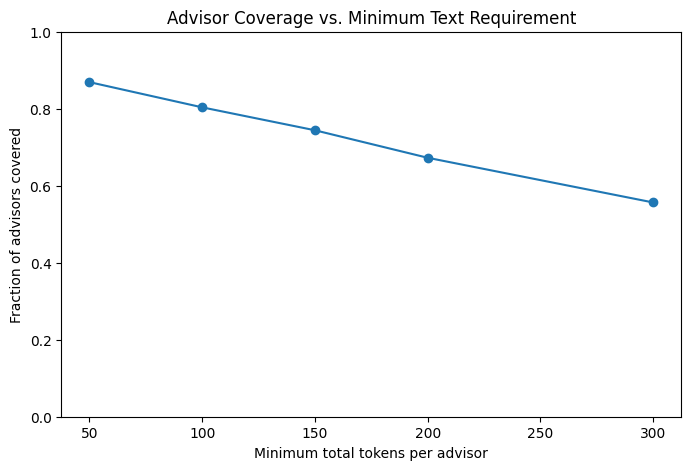

In [ ]:
thresholds = [50, 100, 150, 200, 300]
coverage = [
    (advisor_lang["total_tokens"] >= t).mean()
    for t in thresholds
]

plt.figure(figsize=(8,5))
plt.plot(thresholds, coverage, marker="o")
plt.xlabel("Minimum total tokens per advisor")
plt.ylabel("Fraction of advisors covered")
plt.title("Advisor Coverage vs. Minimum Text Requirement")
plt.ylim(0,1)
plt.show()

**Comment:** Approx 3/4 of advisors already have enough review text (>=150 total tokens) to support quantitative relationship insights. For the rest, we would use lighter, qualitative reporting.

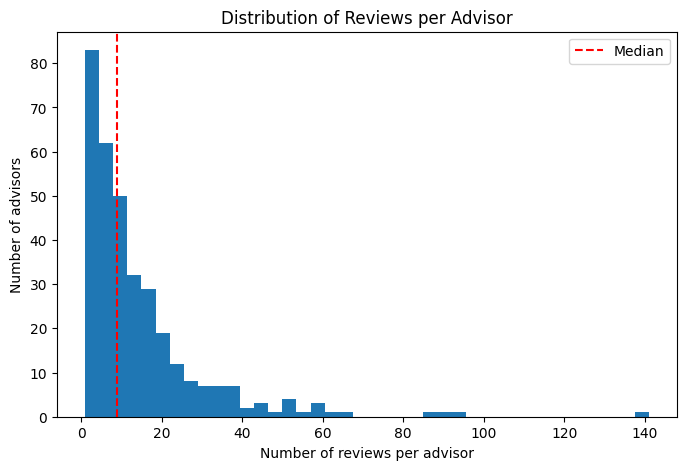

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(advisor_lang["n_reviews"], bins=40)
plt.axvline(advisor_lang["n_reviews"].median(), color="red", linestyle="--", label="Median")
plt.xlabel("Number of reviews per advisor")
plt.ylabel("Number of advisors")
plt.title("Distribution of Reviews per Advisor")
plt.legend()
plt.show()

In [ ]:
# who are the advisors with more informative reviews >= 4 stars
df_4plus = df[df["acf_rating"] >= 4].copy()

print("Total reviews:", len(df))
print("4+ star reviews:", len(df_4plus))

Total reviews: 4723
4+ star reviews: 4651


In [ ]:
INFORMATIVE_TOKENS = 75 # i chose 75 which is 2 times the median review length

df_4plus["informative"] = df_4plus["n_tokens"] >= INFORMATIVE_TOKENS

df_4plus["informative"].mean()

np.float64(0.41474951623306816)

In [ ]:
advisor_info = (
    df_4plus
    .groupby("advisor_id")
    .agg(
        advisor_name=("advisor_name", "first"),
        n_reviews_4plus=("informative", "size"),
        n_informative_4plus=("informative", "sum"),
        share_informative_4plus=("informative", "mean"),
        avg_tokens_4plus=("n_tokens", "mean")
    )
    .reset_index()
)

MIN_REVIEWS = 5

advisor_info_valid = advisor_info[
    advisor_info["n_reviews_4plus"] >= MIN_REVIEWS
].copy()

print("Advisors with ≥5 high-star reviews:", len(advisor_info_valid))

Advisors with ≥5 high-star reviews: 249


In [ ]:
advisor_info_valid.sort_values(
    "share_informative_4plus", ascending=False
).head(10)

,advisor_id,advisor_name,n_reviews_4plus,n_informative_4plus,share_informative_4plus,avg_tokens_4plus
78,https://wealthtender.com/financial-advisors/br...,"Bryan Huhn, CFP®",6,6,1.000000,243.166667
132,https://wealthtender.com/financial-advisors/dw...,"Dwight Dettloff, CPA/PFS, CFP®",5,5,1.000000,123.400000
36,https://wealthtender.com/advisory-firms/sanctu...,Sanctuary Financial Planning,15,14,0.933333,151.466667
83,https://wealthtender.com/financial-advisors/ch...,"Chad Bester, CFP®",9,8,0.888889,114.222222
74,https://wealthtender.com/financial-advisors/br...,"Brett Tushingham, CFP®",17,15,0.882353,143.647059
318,https://wealthtender.com/financial-coaches/mvm...,MVMT Life Planning,8,7,0.875000,175.125000
48,https://wealthtender.com/financial-advisors/al...,"Alexis Hongamen, CFP®, CRPC®",7,6,0.857143,139.285714
250,https://wealthtender.com/financial-advisors/ni...,"Nick Morrison, MBA, CFP®",7,6,0.857143,93.000000
105,https://wealthtender.com/financial-advisors/da...,"Daniel Kopp, CFP®, MA",21,18,0.857143,131.238095
263,https://wealthtender.com/financial-advisors/pr...,"Preston Forman, CFP®",7,6,0.857143,97.571429


**Comment:** These advisors consistently receive detailed feedback from satisfied clients.

In [ ]:
df.head(2)

,ID,Title,Content,Date,_custom_form,notification_name,notification_page,_custom_relationship,_custom_compensation,_custom_conflicts,...,clean_len,char_len,word_len,tokens,n_tokens,tokens_nostop,n_tokens_nostop,review_text_clean2,bigrams,trigrams
0,55476,Absolutely amazing!!!,Omar Morillo is an exceptional wealth advisor ...,2026-01-07 15:15:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,516,516,93,"[omar, morillo, is, an, exceptional, wealth, a...",93,"[omar, morillo, exceptional, person., goes, be...",45,omar morillo is an exceptional wealth advisor ...,"[(omar, morillo), (morillo, exceptional), (exc...","[(omar, morillo, exceptional), (morillo, excep..."
1,55446,It is Simply wonderful working with Omar,Omar is an exceptional advisor. Beyond the out...,2026-01-06 20:44:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,316,316,47,"[omar, is, an, exceptional, advisor., beyond, ...",47,"[omar, exceptional, advisor., beyond, outstand...",27,omar is an exceptional advisor. beyond the out...,"[(omar, exceptional), (exceptional, advisor.),...","[(omar, exceptional, advisor.), (exceptional, ..."


In [ ]:
df['ID'].size

4723

In [ ]:
# df.columns

# 2. Semantic relationship dimensions using dense embedding models

In [ ]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import re

In [ ]:
# Choose and load an embedding model
# 'all-MiniLM-L6-v2' is a fast and effective general-purpose model.
model = SentenceTransformer('all-MiniLM-L6-v2')
# model = SentenceTransformer('Alibaba-NLP/gte-multilingual-base', trust_remote_code=True)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# read only a few of the reviews, JUST A SAMPLE TO CHECK IF COSINE SIMILARITIES MAKE SENSE

sample_df = (
    df[df["n_tokens"] >= 10]   # avoid trivial reviews
      .sample(10, random_state=42)
      .reset_index(drop=True)
)

sample_texts = sample_df["review_text_clean2"].tolist()

sample_texts

['my wife and i have been utilizing zack’s services for almost two years now and could not recommend him more. his expertise and professional connections have helped our family not only save thousands in unnecessary costs but have helped put us in a position to launch our own business. our dream of owning a business could not have been possible without the help of zack and his services.',
 "my wife and i engaged kevin's services in the winter of 2022. i thought i had a good grip on our finances until we met him. he was able to use visual aids to explain our current situation and what levers we can pull to alter our path. he shed light on some strategies that helped us make considerations on our financial future and encouraged me to step outside my comfort zone to consider ways to optimize my finances. i'm thankful that he wasn't afraid to have tough, yet enlightening, conversations to help give us a full picture of our strategy going forward. be prepared to have open and honest convers

In [ ]:
# generate emdeddings
embeddings = model.encode(
    sample_texts,
    show_progress_bar=True
)

embeddings.shape

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(10, 384)

10 reviews (sample) and a 384-dimensional vector

In [ ]:
# similarity matrix

sim_matrix = cosine_similarity(embeddings)
sim_matrix

array([[1.0000002 , 0.4318273 , 0.5572322 , 0.45559245, 0.27921975,
        0.47748774, 0.40965867, 0.20973575, 0.31756526, 0.51395416],
       [0.4318273 , 1.        , 0.57121575, 0.37470183, 0.46286964,
        0.3552615 , 0.47465122, 0.3434656 , 0.29964608, 0.49738866],
       [0.5572322 , 0.57121575, 0.9999999 , 0.4918852 , 0.37722653,
        0.4313035 , 0.38392073, 0.35955048, 0.34455556, 0.57272446],
       [0.45559245, 0.37470183, 0.4918852 , 1.        , 0.39687783,
        0.48822784, 0.34510675, 0.39829475, 0.16762537, 0.45201087],
       [0.27921975, 0.46286964, 0.37722653, 0.39687783, 1.0000002 ,
        0.28581938, 0.32678545, 0.2768076 , 0.2675457 , 0.4236459 ],
       [0.47748774, 0.3552615 , 0.4313035 , 0.48822784, 0.28581938,
        1.0000001 , 0.28590697, 0.3013112 , 0.24581641, 0.36418015],
       [0.40965867, 0.47465122, 0.38392073, 0.34510675, 0.32678545,
        0.28590697, 1.        , 0.23260862, 0.1580563 , 0.6103001 ],
       [0.20973575, 0.3434656 , 0.3595504

In [ ]:
# review if top similarities make sense
for i in range(len(sample_df)):
    sims = sim_matrix[i]
    top_matches = np.argsort(sims)[::-1][1:4]  # skip self

    print("\n" + "="*80)
    print(f"Review {i}")
    print(f"Advisor: {sample_df.loc[i, 'advisor_name']} "
          f"(ID: {sample_df.loc[i, 'advisor_id']})")
    print(f"Review date: {sample_df.loc[i, 'review_date']}")
    print(f"Review length (tokens): {sample_df.loc[i, 'n_tokens']}")
    print(f"Text: {sample_df.loc[i, 'review_text_clean2'][:200]}...")
    print("\nTop similar reviews:")

    for j in top_matches:
        print(f"\n  Similarity: {sims[j]:.3f}")
        print(f"  Advisor: {sample_df.loc[j, 'advisor_name']} "
              f"(ID: {sample_df.loc[j, 'advisor_id']})")
        print(f"  Review date: {sample_df.loc[j, 'review_date']}")
        print(f"  Review length (tokens): {sample_df.loc[j, 'n_tokens']}")
        print(f"  Text: {sample_df.loc[j, 'review_text_clean2'][:200]}...")


Review 0
Advisor: Zack Gutches, CFP®, CPA (ID: https://wealthtender.com/financial-advisors/zack-gutches-cfp-cpa/)
Review date: 2024-12-17 15:36:00
Review length (tokens): 68
Text: my wife and i have been utilizing zack’s services for almost two years now and could not recommend him more. his expertise and professional connections have helped our family not only save thousands i...

Top similar reviews:

  Similarity: 0.557
  Advisor: Capital Fiduciary Advisors (ID: https://wealthtender.com/advisory-firms/capital-fiduciary-advisors/)
  Review date: 2021-12-09 00:00:00
  Review length (tokens): 49
  Text: been working with chris for over 5 years now. he has been an invaluable asset in helping me get my arms around financial planning for my family and our future. i would wholeheartedly recommend his ser...

  Similarity: 0.514
  Advisor: Blake Jones, CFP®, EA, CBDA (ID: https://wealthtender.com/financial-advisors/blake-jones-cfp-ea-cbda/)
  Review date: 2024-01-11 23:04:00
  Review lengt

## 2.1. Create embeddings

In [ ]:
# Keep only rows with usable text (more than 5 tokens)
df_embed = df[
    df["review_text_clean2"].notna()
    & df["review_text_clean2"].str.strip().ne("")
    & (df["n_tokens"] >= 5)
].copy()

print("Original rows:", len(df))
print("Embedding rows:", len(df_embed))
print(df_embed["n_tokens"].describe())

Original rows: 4723
Embedding rows: 4579
count    4579.000000
mean       80.019437
std        65.970921
min         5.000000
25%        40.000000
50%        66.000000
75%       103.000000
max      2048.000000
Name: n_tokens, dtype: float64


### Encode in batches

In [ ]:
texts = df_embed["review_text_clean2"].tolist()

embeddings = model.encode(
    texts,
    batch_size=64,              # safe default; if GPU available you can increase later
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # makes cosine similarity = dot product
)

embeddings.shape

Batches:   0%|          | 0/72 [00:00<?, ?it/s]

(4579, 384)

### Attach embeddings to dataframe

In [ ]:
df_embed = df_embed.reset_index(drop=True)
df_embed["embedding"] = list(embeddings)

df_embed[["advisor_name", "advisor_id", "n_tokens", "embedding"]].head()

,advisor_name,advisor_id,n_tokens,embedding
0,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,93,"[-0.015374815, -0.003500422, -0.020433187, 0.0..."
1,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,47,"[-0.03322719, 0.027206246, -0.021586968, 0.077..."
2,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,142,"[0.025963664, 0.0017665024, -0.040333986, 0.09..."
3,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,26,"[-0.07698585, 0.006825544, -0.0862981, 0.05765..."
4,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,91,"[-0.009434393, 0.04345492, -0.05002322, 0.0357..."


In [ ]:
df_embed["embedding"].iloc[0].shape

(384,)

In [ ]:
df['review_text_clean2'].head(1)

,review_text_clean2
0,omar morillo is an exceptional wealth advisor ...


In [ ]:
i = 0  # try a couple different i values later
sims = embeddings @ embeddings[i]     # fast similarity to all (because normalized)
top = np.argsort(sims)[::-1][1:6]     # skip self

df_embed.loc[top, ["advisor_name", "advisor_id", "n_tokens", "review_text_clean2"]].head()

,advisor_name,advisor_id,n_tokens,review_text_clean2
2,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,142,we are extremely happy with the work omar mori...
4,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,91,omar was referred to me by my accountant to he...
1,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,47,omar is an exceptional advisor. beyond the out...
5,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,130,"i reached out to omar a couple of years ago, j..."
396,Bouchey Financial Group,https://wealthtender.com/advisory-firms/bouche...,87,paolo at bouchey financial group has been an o...


People is mentioning names a lot, which can cause embeddings cluster by **who** rather than by **what relationship qualities**

In [ ]:
df_embed["review_text_clean2"].str.contains("omar", case=False, na=False).mean()

np.float64(0.001310329766324525)

In [ ]:
(df_embed.apply(lambda r: isinstance(r["advisor_name"], str) and r["advisor_name"].split(",")[0].lower() in r["review_text_clean2"].lower(),
               axis=1)).mean()

np.float64(0.16051539637475432)

So approx 16% of reviews mention advisor's name

Ignoring the same advisor, what are most semantically similar reviews?

In [ ]:
i = 0
same_advisor = df_embed["advisor_id"] == df_embed.loc[i, "advisor_id"]

# similarities excluding same-advisor reviews
sims = embeddings @ embeddings[i]
sims_excl = sims.copy()
sims_excl[same_advisor.values] = -1  # remove same-advisor matches

top = np.argsort(sims_excl)[::-1][:5]

df_embed.loc[top, ["advisor_name","advisor_id","n_tokens","review_text_clean2"]]

,advisor_name,advisor_id,n_tokens,review_text_clean2
396,Bouchey Financial Group,https://wealthtender.com/advisory-firms/bouche...,87,paolo at bouchey financial group has been an o...
1611,"Amir Noor, CFP®",https://wealthtender.com/financial-advisors/am...,64,amir has proven himself to be a long term comm...
1613,"Amir Noor, CFP®",https://wealthtender.com/financial-advisors/am...,92,we’ve been working with amir for several years...
3650,"David Warshaw, CFP®, CLU®, ChFC®",https://wealthtender.com/financial-advisors/da...,107,david is an outstanding financial advisor who ...
1607,"Amir Noor, CFP®",https://wealthtender.com/financial-advisors/am...,96,we have been working with amir for the last 4 ...


In [ ]:
# compute time difference in years
today = pd.Timestamp.today()

df_embed["review_date"] = pd.to_datetime(
    df_embed["review_date"],
    errors="coerce"
)

df_embed["age_years"] = (today - df_embed["review_date"]).dt.days / 365.25

df_embed["age_years"].describe()

,age_years
count,4579.000000
mean,1.914262
std,1.439912
min,0.106776
25%,0.835044
50%,1.648186
75%,2.505133
max,17.226557


## Drop advisor's names from reviews and run embeddings again

In [ ]:
def normalize_name(name: str) -> str:
    name = str(name).lower()
    # remove credentials and punctuation-ish clutter
    name = re.sub(r"cfa|cfp|chfc|aif|cpa|mba|phd|ms|jd|esq", " ", name)
    name = re.sub(r"[^a-z\s]", " ", name)   # keep only letters/spaces
    name = re.sub(r"\s+", " ", name).strip()
    return name

def remove_advisor_identity(row):
    text = str(row["review_text_clean2"]).lower()
    adv = normalize_name(row["advisor_name"])

    parts = adv.split()
    first = parts[0] if len(parts) else ""
    last  = parts[-1] if len(parts) else ""

    # remove full normalized name phrase if it appears
    if adv:
        text = re.sub(rf"\b{re.escape(adv)}\b", " ", text)

    # remove first and last name tokens
    for token in {first, last}:
        if token and len(token) >= 3:  # avoid nuking short tokens like "li"
            text = re.sub(rf"\b{re.escape(token)}\b", " ", text)

    # clean spacing
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_embed["review_text_clean2"] = df_embed.apply(remove_advisor_identity, axis=1)

In [ ]:
# Load model (same one used before)
model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df_embed["review_text_clean2"].tolist()

embeddings = model.encode(
    texts,
    batch_size=64,              # safe default; if GPU available you can increase later
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # makes cosine similarity = dot product
)

embeddings.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

(4579, 384)

In [ ]:
df_embed = df_embed.reset_index(drop=True)
df_embed["embedding"] = list(embeddings)

df_embed[["advisor_name", "advisor_id", "n_tokens", "embedding","age_years"]].head()

,advisor_name,advisor_id,n_tokens,embedding,age_years
0,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,93,"[-0.029703345, 0.04847767, -0.034020364, 0.005...",0.106776
1,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,47,"[-0.052020203, 0.014893077, -0.012456992, 0.00...",0.109514
2,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,142,"[-0.0032731362, 0.042736255, -0.068086535, 0.0...",0.109514
3,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,26,"[-0.07698585, 0.006825544, -0.0862981, 0.05765...",0.109514
4,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,91,"[-0.04333346, 0.057677966, -0.05204436, -0.055...",0.109514


In [ ]:
df_embed.head(2)

,ID,Title,Content,Date,_custom_form,notification_name,notification_page,_custom_relationship,_custom_compensation,_custom_conflicts,...,word_len,tokens,n_tokens,tokens_nostop,n_tokens_nostop,review_text_clean2,bigrams,trigrams,embedding,age_years
0,55476,Absolutely amazing!!!,Omar Morillo is an exceptional wealth advisor ...,2026-01-07 15:15:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,93,"[omar, morillo, is, an, exceptional, wealth, a...",93,"[omar, morillo, exceptional, person., goes, be...",45,is an exceptional wealth advisor and person. h...,"[(omar, morillo), (morillo, exceptional), (exc...","[(omar, morillo, exceptional), (morillo, excep...","[-0.029703345, 0.04847767, -0.034020364, 0.005...",0.106776
1,55446,It is Simply wonderful working with Omar,Omar is an exceptional advisor. Beyond the out...,2026-01-06 20:44:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,...,47,"[omar, is, an, exceptional, advisor., beyond, ...",47,"[omar, exceptional, advisor., beyond, outstand...",27,is an exceptional advisor. beyond the outstand...,"[(omar, exceptional), (exceptional, advisor.),...","[(omar, exceptional, advisor.), (exceptional, ...","[-0.052020203, 0.014893077, -0.012456992, 0.00...",0.109514


In [ ]:
df_embed[['ID', 'Title', 'Date', 'Status', 'reviewer_name','rating', 'n_tokens','tokens_nostop','n_tokens_nostop','bigrams']]

,ID,Title,Date,Status,reviewer_name,rating,n_tokens,tokens_nostop,n_tokens_nostop,bigrams
0,55476,Absolutely amazing!!!,2026-01-07 15:15:00,publish,Alyssa Sussman,5.0,93,"[omar, morillo, exceptional, person., goes, be...",45,"[(omar, morillo), (morillo, exceptional), (exc..."
1,55446,It is Simply wonderful working with Omar,2026-01-06 20:44:00,publish,Nayarit Briceno,5.0,47,"[omar, exceptional, advisor., beyond, outstand...",27,"[(omar, exceptional), (exceptional, advisor.),..."
2,55445,President,2026-01-06 20:44:00,publish,Gregory Gutt,5.0,142,"[extremely, happy, work, omar, morillo, done, ...",72,"[(extremely, happy), (happy, work), (work, oma..."
3,55443,Great service,2026-01-06 20:43:00,publish,anonymous,5.0,26,"[available, questions, concerns,, schedules, r...",11,"[(available, questions), (questions, concerns,..."
4,55444,Recommending Omar Morillo,2026-01-06 20:43:00,publish,Ron,5.0,91,"[omar, referred, accountant, help, setup, defi...",48,"[(omar, referred), (referred, accountant), (ac..."
...,...,...,...,...,...,...,...,...,...,...
4574,27290,Five Stars,2016-11-09 00:00:00,publish,Lori Z.,5.0,54,"[russ, generous, time, knowledge., gives, grea...",23,"[(russ, generous), (generous, time), (time, kn..."
4575,27287,Five Stars,2016-09-01 00:00:00,publish,Sam L.,5.0,79,"[russ, incredibly, smart, knowledgeable, money...",31,"[(russ, incredibly), (incredibly, smart), (sma..."
4576,27282,5 Stars,2016-08-25 00:00:00,publish,Emily Knab,5.0,17,"[russ, amazing., opportunity,, work, him., tha...",7,"[(russ, amazing.), (amazing., opportunity,), (..."
4577,27283,5 Stars,2014-11-13 00:00:00,publish,Dr. Mary Gresham,5.0,72,"[russ, trustworthy, specializes, working, wome...",33,"[(russ, trustworthy), (trustworthy, specialize..."


In [ ]:
df_embed.columns

Index(['ID', 'Title', 'Content', 'Date', '_custom_form', 'notification_name',
       'notification_page', '_custom_relationship', '_custom_compensation',
       '_custom_conflicts', '_custom_disclosure', 'Status',
       'Post Modified Date', 'reviewer_name', 'acf_rating', 'advisor_id',
       'advisor_name', 'review_text_raw', 'rating', 'review_date',
       'token_count', 'review_text_clean', 'clean_token_count', 'raw_len',
       'clean_len', 'char_len', 'word_len', 'tokens', 'n_tokens',
       'tokens_nostop', 'n_tokens_nostop', 'review_text_clean2', 'bigrams',
       'trigrams', 'embedding', 'age_years'],
      dtype='object')

In [ ]:
# SAVE DATASET
df_save = df_embed.copy()
df_save = df_save.rename(columns = {"_custom_relationship":"custom_relationship",
                                    "_custom_compensation":"custom_compensation",
                                    "_custom_conflicts":"custom_conflicts",
                                    "n_tokens":"total_tokens_raw",
                                    "review_text_clean2":"review_text_processed",
                                    "tokens_nostop":"tokens_processed",
                                    "n_tokens_nostop":"n_tokens_processed"})
df_save = df_save[[
    'ID',
    'Title',
    'Date',
    'age_years',
    'custom_relationship',
    'custom_compensation',
    'reviewer_name',
    'advisor_id',
    'advisor_name',
    'acf_rating',
    'rating',
    'review_text_raw',
    'total_tokens_raw',
    'review_text_processed',
    'tokens_processed',
    'n_tokens_processed',
    'embedding',
    'bigrams',
    'trigrams'
]]

df_save.to_csv('df_embeddings_MVP.csv', index=False)

### Create review-embeddings table

In [ ]:
review_emb = df_embed[[
    "advisor_id",
    "advisor_name",
    "review_date",
    "age_years",
    "n_tokens",
    "review_text_clean2",
    "embedding"
]].copy()

review_emb = review_emb.reset_index(drop=True)

review_emb.head()

,advisor_id,advisor_name,review_date,age_years,n_tokens,review_text_clean2,embedding
0,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",2026-01-07 15:15:00,0.106776,93,is an exceptional wealth advisor and person. h...,"[-0.029703345, 0.04847767, -0.034020364, 0.005..."
1,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",2026-01-06 20:44:00,0.109514,47,is an exceptional advisor. beyond the outstand...,"[-0.052020203, 0.014893077, -0.012456992, 0.00..."
2,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",2026-01-06 20:44:00,0.109514,142,we are extremely happy with the work has done ...,"[-0.0032731362, 0.042736255, -0.068086535, 0.0..."
3,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",2026-01-06 20:43:00,0.109514,26,always available for any questions or concerns...,"[-0.07698585, 0.006825544, -0.0862981, 0.05765..."
4,https://wealthtender.com/financial-advisors/om...,"Omar A. Morillo, CFP®, ChFC®, AIF®",2026-01-06 20:43:00,0.109514,91,was referred to me by my accountant to help se...,"[-0.04333346, 0.057677966, -0.05204436, -0.055..."


### Create advisor-level baseline

In [ ]:
# Build a review-level working table (keep only what we need)
reviews = review_emb.copy().rename(columns = {
                                    "n_tokens":"n_tokens_raw",
                                    "review_text_clean2":"review_text_processed",
                                    "tokens_nostop":"tokens_processed",
                                    "n_tokens_nostop":"n_tokens_processed"})



reviews = reviews[[
    "advisor_id",
    "advisor_name",
    "n_tokens_raw",
    "age_years",
    "embedding"
    # "review_text_processed"
]]

# Turn the list of vectors into a matrix: one row per review
emb_matrix = np.vstack(reviews["embedding"].to_numpy())  # shape: (n_reviews, 384)

# Group review row indices by advisor_id
advisor_to_rows = reviews.groupby(["advisor_id"]).indices

# Aggregate reviews -> advisor profile
advisor_records = []
advisor_vectors = []

for advisor_id, rows in advisor_to_rows.items():
    rows = np.array(list(rows))

    # advisor embedding = average of their review embeddings (baseline)
    v = emb_matrix[rows].mean(axis=0)
    v = v / np.linalg.norm(v)  # normalize for cosine similarity

    advisor_vectors.append(v)

    advisor_records.append({
        "advisor_id": advisor_id,
        "advisor_name": reviews.loc[rows[0], "advisor_name"],
        "n_reviews": len(rows),
        "n_tokens_raw": int(reviews.loc[rows, "n_tokens_raw"].sum()),
        "median_age_years": float(np.median(reviews.loc[rows, "age_years"])),
        # "review_text_processed": review_text_processed
    })

# Final outputs
advisor_vecs = np.vstack(advisor_vectors)          # (n_advisors, 384)
advisors_df = pd.DataFrame(advisor_records)        # one row per advisor

advisor_vecs.shape, advisors_df["n_reviews"].describe()

((334, 384),
 count    334.000000
 mean      13.706587
 std       15.474793
 min        1.000000
 25%        5.000000
 50%        9.000000
 75%       17.000000
 max      135.000000
 Name: n_reviews, dtype: float64)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_adv = cosine_similarity(advisor_vecs)

k = 5
i = 0  # test a few random advisors

top = np.argsort(sim_adv[i])[::-1][1:k+1]

print("Query advisor:", advisors_df.loc[i, "advisor_name"])
advisors_df.loc[top, ["advisor_name", "n_reviews", "median_age_years"]]

Query advisor: Press Advisor Test


,advisor_name,n_reviews,median_age_years
267,Press Advisor Test,1,4.881588
309,TEST ADVISOR August 2022,3,3.501711
127,"Jane Demo, CFZ®",12,1.934292
223,Mark Primeau,4,0.542094
328,The MoneyRx for CRNAs Podcast,1,0.966461


## Embeddings approach 1: penalize based on how old is the advisor's most recent review

Assumption: if an advisor's newest review is old, their profile is less representative of "today" so we apply a stronger penalty.

$\ $

For this we can define $t_a^{max}$ as the date of the most recent review for advisor $a$ and $T$ represents "today". So:

$\ $

$staleness_a = \frac{T-t_a^{max}}{365.25}$

$\ $

Then we can convert this staleness into a penalty using a smooth decay:

$\ $

$p_a=e^{-\lambda \  ̇ \ staleness_a}$

$\ $

Where $\lambda > 0$ controls how fast we downweight outdated profiles. Here we're defining $\lambda$ as the p75 of $ staleness_a$ and our target penalty is $p75 = 0.7$, meaning that at 75th percentile staleness, keep only 70% weight.

$ \$

So, $\lambda = \frac{-\ln(0.7)}{p_{75}}$

In [ ]:
advisor_recency = (
    review_emb.groupby("advisor_id")["review_date"]
    .max()
    .reset_index()
    .rename(columns={"review_date": "most_recent_review_date"})
)

advisor_recency["staleness_years"] = (today - advisor_recency["most_recent_review_date"]).dt.days / 365.25

advisor_recency["staleness_years"].describe()

,staleness_years
count,334.000000
mean,1.049113
std,0.970547
min,0.106776
25%,0.323751
50%,0.740589
75%,1.538672
max,4.881588


**Comment:** median advisor's most recent review is ~0.73 years old (8-9 months)


In [ ]:
s75 = advisor_recency["staleness_years"].quantile(0.75)
target_penalty_at_s75 = 0.7

lam = -np.log(target_penalty_at_s75) / s75

s75, lam

(np.float64(1.538672142368241), np.float64(0.2318069809139182))

In [ ]:
advisor_recency["penalty_factor"] = np.exp(-lam * advisor_recency["staleness_years"])
advisor_recency["penalty_factor"].describe()

,penalty_factor
count,334.000000
mean,0.802005
std,0.153960
min,0.322521
25%,0.700000
50%,0.842254
75%,0.927699
max,0.975552


In [ ]:
advisors_df = advisors_df.merge(
    advisor_recency[["advisor_id", "most_recent_review_date", "staleness_years", "penalty_factor"]],
    on="advisor_id",
    how="left"
)

advisors_df[["advisor_name", "n_reviews", "most_recent_review_date", "staleness_years", "penalty_factor"]].head()

,advisor_name,n_reviews,most_recent_review_date,staleness_years,penalty_factor
0,Press Advisor Test,1,2021-03-30 18:24:00,4.881588,0.322521
1,Abundo Wealth,34,2025-08-03 17:44:00,0.536619,0.883034
2,"Allegiance Financial Group Advisory Services, LLC",12,2025-10-14 13:33:00,0.339493,0.924320
3,Applied Capital,22,2025-02-12 16:19:00,1.007529,0.791716
4,Archer Investment Management,14,2025-05-09 13:17:00,0.772074,0.836129


In [ ]:
advisor_vecs_penalized = advisor_vecs * advisors_df["penalty_factor"].values[:, None]

In [ ]:
advisors_df["advisor_embedding_mean"] = list(advisor_vecs)

In [ ]:
advisor_vecs_penalized = advisor_vecs * advisors_df["penalty_factor"].values[:, None]
advisors_df["advisor_embedding_penalized"] = list(advisor_vecs_penalized)

In [ ]:
advisors_df.head()

,advisor_id,advisor_name,n_reviews,n_tokens_raw,median_age_years,most_recent_review_date,staleness_years,penalty_factor,advisor_embedding_mean,advisor_embedding_penalized
0,Press Advisor Test,Press Advisor Test,1,6,4.881588,2021-03-30 18:24:00,4.881588,0.322521,"[-0.07958292, 0.06273659, -0.044504944, 0.0498...","[-0.025667185789726862, 0.020233886233675245, ..."
1,https://wealthtender.com/advisory-firms/abundo...,Abundo Wealth,34,3488,2.024641,2025-08-03 17:44:00,0.536619,0.883034,"[0.0048418697, 0.0033741083, -0.023717595, 0.0...","[0.004275533858744347, 0.002979451199641809, -..."
2,https://wealthtender.com/advisory-firms/allegi...,"Allegiance Financial Group Advisory Services, LLC",12,723,0.662560,2025-10-14 13:33:00,0.339493,0.924320,"[-0.036089465, -0.0013664401, -0.05340905, 0.0...","[-0.03335821378314329, -0.0012630278843946071,..."
3,https://wealthtender.com/advisory-firms/applie...,Applied Capital,22,1639,1.200548,2025-02-12 16:19:00,1.007529,0.791716,"[-0.06905865, 0.028923973, -0.029958587, -0.00...","[-0.05467485180654553, 0.022899578530850596, -..."
4,https://wealthtender.com/advisory-firms/archer...,Archer Investment Management,14,1799,1.518138,2025-05-09 13:17:00,0.772074,0.836129,"[-0.0013577266, 0.04729851, -0.027007045, -0.0...","[-0.0011352348947660132, 0.03954766531228501, ..."


In [ ]:
advisors_df.to_parquet("advisor_embeddings_MVP.parquet", index=False)

## Embeddings Approach 2: weighted average by time AND text length

### Weighted average
We want advisor-level embeddings that reflect:
1) recency, and
2) informativeness (longer & more detailed reviews matter more)

Conceptually it would be something like:

$advisor\ embedding
=
\frac{\sum_i w_i \cdot \text{embedding}_i}{\sum_i w_i}$